In [2]:
import json
import glob
import torch
import pyspark
import findspark
import torch.nn as nn
from pyspark.sql import SparkSession
from sklearn.model_selection import train_test_split

In [3]:
# spark = SparkSession.builder.appName("JsonExtractor").getOrCreate()

findspark.init()

spark = SparkSession.builder \
    .appName("JsonExtractor") \
    .config("spark.driver.port", "5000")\
    .config("spark.blockManager.port", "4000")\
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

25/02/17 14:28:05 WARN Utils: Your hostname, victors-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.2.43.32 instead (on interface en0)
25/02/17 14:28:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/17 14:28:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
dir = "archive/batch_*/json/kaggle_data_*.json"

json_files = glob.glob(dir)

sorted(json_files)

['archive/batch_1/json/kaggle_data_1.json',
 'archive/batch_10/json/kaggle_data_10.json',
 'archive/batch_2/json/kaggle_data_2.json',
 'archive/batch_3/json/kaggle_data_3.json',
 'archive/batch_4/json/kaggle_data_4.json',
 'archive/batch_5/json/kaggle_data_5.json',
 'archive/batch_6/json/kaggle_data_6.json',
 'archive/batch_7/json/kaggle_data_7.json',
 'archive/batch_8/json/kaggle_data_8.json',
 'archive/batch_9/json/kaggle_data_9.json']

In [11]:
with open(json_files[1]) as file:
    data = json.load(file)

# print(data)

In [9]:
image_data = spark.read.json(json_files[1])

In [10]:
image_data.show()

+--------------------+-------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|   font|          image_data|               latex|unicode_less_curlies|         unicode_str|                uuid|
+--------------------+-------+--------------------+--------------------+--------------------+--------------------+--------------------+
|0e349329-7cbc-46d...| Oct_71|{4, [\lim_, {, u,...|\lim_{u\to7^{+}}\...|      ƀuƄ7^+Ƃu+-3ಭ4u|ƀ{uƄ7^{+}}Ƃ{u}+-3...|0e349329-7cbc-46d...|
|43bf5de9-04db-42d...|Oct_031|{4, [\lim_, {, v,...|\lim_{v\to7/7}\fr...|ƀvƄ7/7ಭ3v+-5Ɖೃv3v...|ƀ{vƄ7/7}ಭ{3v+-5Ɖ{...|43bf5de9-04db-42d...|
|a7164e3f-0f1d-448...|Oct_056|{4, [\lim_, {, r,...|\lim_{r\to\infty}...|    ƀrƄಲಭ8ೡr^1r+-8ur|ƀ{rƄಲ}ಭ{8ೡ{r^{1}}...|a7164e3f-0f1d-448...|
|97cf4a59-6521-436...|Oct_116|{4, [\lim_, {, u,...|\lim_{u\to\infty}...|      ƀuƄಲಭu+Ƈu7u+Ɖu|ƀ{uƄಲ}ಭ{u+Ƈ{u}}{7...|97cf4a59-6521-436...|
|b1c1ac11-0a8c-482...|   C082|{4, [\lim_, {, y,.

In [12]:
from pyspark.sql.functions import StructType, explode, col
from pyspark.sql.types import IntegerType, FloatType, DoubleType, StringType, StructType, StructField

image_prop = spark.createDataFrame([],
                schema = StructType([
                    StructField('full_latex_chars', StringType()),
                    StructField('visible_latex_chars', StringType()),
                    StructField('visible_char_map', StringType()),
                    StructField('width', FloatType()),
                    StructField('height', FloatType()),
                    StructField('depth', FloatType()),
                    StructField('xmins', DoubleType()),
                    StructField('ymins', DoubleType()),
                    StructField('xmaxs', DoubleType()),
                    StructField('ymaxs', DoubleType()),
                    StructField('xmins_raw', IntegerType()),
                    StructField('ymins_raw', IntegerType()),
                    StructField('xmaxs_raw', IntegerType()),
                    StructField('ymaxs_raw', IntegerType()),
                ])
            )

In [13]:
image_label = image_data.select(explode('image_data.full_latex_chars').alias('image'))

In [15]:
# image_label.show()

In [16]:
# image_label_array = image_data.select('image_data.full_latex_chars')

# image_label_array.show(truncate = False)

In [17]:
image_data = image_data.\
                withColumn('full_latex_chars', col('image_data.full_latex_chars')).\
                withColumn('visible_latex_chars', col('image_data.visible_latex_chars')).\
                withColumn('visible_char_map', col('image_data.visible_char_map')).\
                withColumn('width', col('image_data.width')).\
                withColumn('height', col('image_data.height')).\
                withColumn('depth', col('image_data.depth')).\
                withColumn('xmins', col('image_data.xmins')).\
                withColumn('xmaxs', col('image_data.xmaxs')).\
                withColumn('ymins', col('image_data.ymins')).\
                withColumn('ymaxs', col('image_data.ymaxs')).\
                withColumn('xmins_raw', col('image_data.xmins_raw')).\
                withColumn('xmaxs_raw', col('image_data.xmaxs_raw')).\
                withColumn('ymins_raw', col('image_data.ymins_raw')).\
                withColumn('ymaxs_raw', col('image_data.ymaxs_raw')).\
                withColumn('png_masks', col('image_data.png_masks'))

image_data.show()

+--------------------+-------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-----+------+-----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|            filename|   font|          image_data|               latex|unicode_less_curlies|         unicode_str|                uuid|    full_latex_chars| visible_latex_chars|    visible_char_map|width|height|depth|               xmins|               xmaxs|               ymins|               ymaxs|           xmins_raw|           xmaxs_raw|           ymins_raw|           ymaxs_raw|           png_masks|
+--------------------+-------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------

In [ ]:
## A better way to organise the table

# from pyspark.sql.functions import col, concat_ws
# from pyspark.ml.feature import VectorAssembler

# # Example: If you want to convert an array of LaTeX tokens into a single string (if that makes sense for your use case)
# df = df.withColumn("full_latex_string", concat_ws(" ", col("full_latex_chars")))

# # Let's assume you also want to use numeric columns like width, height, and depth as features.
# feature_cols = ["width", "height", "depth"]  # add any other numeric features you need

# # Assemble into a feature vector
# assembler = VectorAssembler(inputCols = feature_cols, outputCol = "features")
# df_transformed = assembler.transform(df)

# # Now df_transformed has a 'features' column that you can use for model training.
# df_transformed.select("features", "latex").show(truncate = False)

In [33]:
# from pyspark.sql.functions import explode, col
# from PIL import Image
# import io

# def decode_png_mask(png_data):
#     """Decodes a PNG string into a Pillow Image object."""
#     try:
#         image = Image.open(io.BytesIO(png_data))
#         return image
#     except Exception as e:
#         # Handle errors (e.g., invalid PNG data)
#         return None

# # Assuming 'df' is your Spark DataFrame
# exploded_df = df.select(
#     "*", 
#     explode(col("image_data.png_masks")).alias("png_mask_data")  # Explode png_masks
# )

# # Decode PNG data to Pillow Image
# decoded_df = exploded_df.rdd.map(
#     lambda row: row + (decode_png_mask(row.png_mask_data),)
# ).toDF(["filename", "font", "image_data", "latex", "unicode_less_curlies", "unicode_str", "uuid", "png_mask_data", "png_mask_image"])

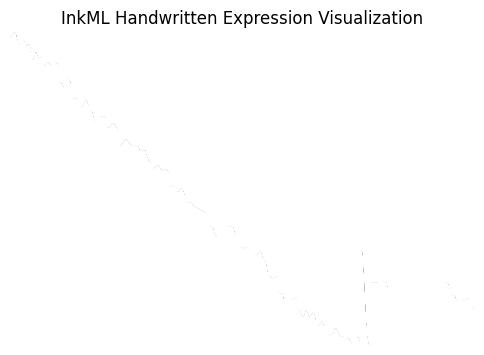

In [6]:
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def parse_inkml(filename):
    ns = {"ink": "http://www.w3.org/2003/InkML"}
    tree = ET.parse(filename)
    root = tree.getroot()
    strokes = []
    # Find all trace elements
    for trace in root.findall(".//ink:trace", ns):
        trace_text = trace.text.strip()
        points = trace_text.split()
        stroke = []
        for pt in points:
            parts = pt.split(',')
            if len(parts) != 2:
                # Skip invalid coordinate entries
                continue
            try:
                x, y = map(float, parts)
                stroke.append((x, y))
            except Exception as e:
                print(f"Error converting {pt}: {e}")
        if stroke:
            strokes.append(stroke)
    return strokes

# Replace with the path to one of your InkML files
filename = "mathwriting/synthetic/0a0b6ce511fa5ba5.inkml"
strokes = parse_inkml(filename)

if not strokes:
    print("No strokes found.")
else:
    # Compute overall bounding box for all strokes
    xs = [x for stroke in strokes for (x, y) in stroke]
    ys = [y for stroke in strokes for (x, y) in stroke]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)

    # Create an image with some padding
    padding = 10
    img_width = int(max_x - min_x) + 2 * padding
    img_height = int(max_y - min_y) + 2 * padding
    img = Image.new("RGB", (img_width, img_height), "white")
    draw = ImageDraw.Draw(img)

    # Draw each stroke (translate coordinates so that min_x, min_y becomes the origin plus padding)
    for stroke in strokes:
        # Optionally, you might invert the y-axis depending on the coordinate system
        stroke_translated = [(x - min_x + padding, y - min_y + padding) for (x, y) in stroke]
        draw.line(stroke_translated, fill="black", width=2)

    # Display the image using Pillow's built-in viewer or matplotlib
    img.show()

    # Alternatively, display with matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("InkML Handwritten Expression Visualization")
    plt.show()